# Notebook 4 - Layer Sweep: Which Layer Encodes Truthfulness Best?

## Goal

Transformer layers do not all represent the same information. Earlier layers often capture surface-level token patterns, while middle and later layers tend to encode more semantic information.

This notebook trains the same probe at every layer and measures where the truthfulness signal is most linearly accessible.


## Step 1 - Setup and dataset selection


In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "lie_detector_llm").exists():
            return candidate
    raise RuntimeError("Could not find the project root. Run this notebook from the repository.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

print(f"Project root: {PROJECT_ROOT}")


Project root: /Users/imadsharof/Library/Mobile Documents/com~apple~CloudDocs/Cours/MA1/Computing Project/Lie-Detector-for-LLM


In [2]:
from lie_detector_llm.datasets import build_dataset_collection

INCLUDE_HF_DATASETS = False
collection = build_dataset_collection(include_hf_datasets=INCLUDE_HF_DATASETS)
frame = collection.subset("repeng_truthful")

print(f"Dataset rows  : {len(frame)}")
print(f"Dataset groups: {frame['group_id'].nunique()}")


Dataset rows  : 108
Dataset groups: 54


## Step 2 - Configure the layer sweep

The model is still `microsoft/phi-2`. Phi-2 has 32 transformer layers, so this experiment trains and evaluates 32 probes for one probe method.

We start with logistic regression because it is a strong supervised baseline.


In [3]:
MODEL_NAME = "microsoft/phi-2"
PROBE_METHOD = "lr"
LOAD_IN_4BIT = False
ACTIVATION_BATCH_SIZE = 2

print("Layer-sweep configuration")
print(f"Model       : {MODEL_NAME}")
print(f"Probe       : {PROBE_METHOD}")
print(f"4-bit load  : {LOAD_IN_4BIT}")


Layer-sweep configuration
Model       : microsoft/phi-2
Probe       : lr
4-bit load  : False


## Step 3 - Run the layer sweep

The function extracts activations once, then trains one probe per layer. The output contains train, validation, and test grouped accuracy for every layer.


In [4]:
from lie_detector_llm.experiment import run_layer_sweep

layer_results = run_layer_sweep(
    frame=frame,
    model_name=MODEL_NAME,
    probe_method=PROBE_METHOD,
    activation_batch_size=ACTIVATION_BATCH_SIZE,
    load_in_4bit=LOAD_IN_4BIT,
    show_progress=True,
)

sweep_table = layer_results.results.pivot_table(
    index="layer",
    columns="split",
    values="grouped_accuracy",
).round(3)

display(sweep_table)


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

Extracting activations:   0%|          | 0/54 [00:00<?, ?it/s]

split,test,train,validation
layer,,,
0,0.818,0.938,0.818
1,0.909,0.969,0.818
2,0.909,1.000,0.909
3,0.909,1.000,0.909
4,0.909,1.000,0.909
5,0.909,1.000,1.000
6,1.000,1.000,1.000
7,1.000,1.000,1.000
8,1.000,1.000,1.000


## Step 4 - Plot accuracy by layer

A clear peak in the middle or later layers is evidence that truthfulness is more accessible at those layers than near the input.


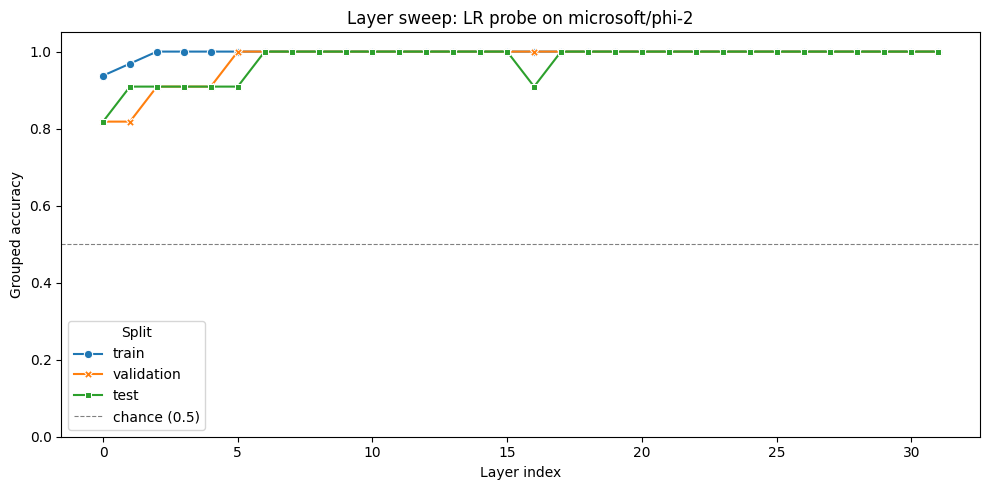

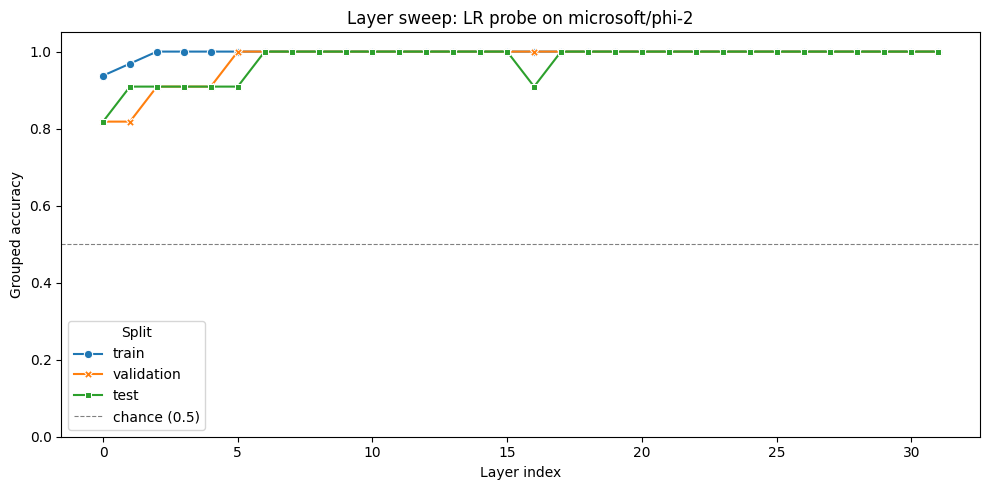

In [5]:
from lie_detector_llm.plotting import plot_layer_sweep

fig, ax = plot_layer_sweep(
    layer_results.results,
    title=f"Layer sweep: {PROBE_METHOD.upper()} probe on {MODEL_NAME}",
)
fig


## Step 5 - Identify the best test layer


In [6]:
test_rows = layer_results.results[layer_results.results["split"] == "test"].copy()
best = test_rows.sort_values("grouped_accuracy", ascending=False).iloc[0]

print(f"Best test layer : {int(best['layer'])}")
print(f"Test accuracy   : {best['grouped_accuracy']:.3f}")
display(test_rows.sort_values("grouped_accuracy", ascending=False).reset_index(drop=True))


Best test layer : 31
Test accuracy   : 1.000


,layer,split,dataset,probe_method,model_name,grouped_accuracy
0,31,test,repeng_truthful,lr,microsoft/phi-2,1.000000
1,13,test,repeng_truthful,lr,microsoft/phi-2,1.000000
2,23,test,repeng_truthful,lr,microsoft/phi-2,1.000000
3,22,test,repeng_truthful,lr,microsoft/phi-2,1.000000
4,21,test,repeng_truthful,lr,microsoft/phi-2,1.000000
5,20,test,repeng_truthful,lr,microsoft/phi-2,1.000000
6,19,test,repeng_truthful,lr,microsoft/phi-2,1.000000
7,18,test,repeng_truthful,lr,microsoft/phi-2,1.000000
8,17,test,repeng_truthful,lr,microsoft/phi-2,1.000000
9,26,test,repeng_truthful,lr,microsoft/phi-2,1.000000


## Step 6 - Optional method comparison across layers

The next cell compares `dim` and `lr` across layers. This is useful because a simpler probe can sometimes reveal a more stable direction, while logistic regression can overfit.


In [7]:
import pandas as pd

method_rows = []
for method in ["dim", "lr"]:
    out = run_layer_sweep(
        frame=frame,
        model_name=MODEL_NAME,
        probe_method=method,
        activation_batch_size=ACTIVATION_BATCH_SIZE,
        load_in_4bit=LOAD_IN_4BIT,
        show_progress=True,
    )
    df_method = out.summary_table()
    df_method["probe_method"] = method
    method_rows.append(df_method)

method_layers = pd.concat(method_rows, ignore_index=True)
test_method_layers = method_layers[method_layers["split"] == "test"]
display(test_method_layers.pivot_table(
    index="layer",
    columns="probe_method",
    values="grouped_accuracy",
).round(3))


Extracting activations:   0%|          | 0/54 [00:00<?, ?it/s]

Extracting activations:   0%|          | 0/54 [00:00<?, ?it/s]

probe_method,dim,lr
layer,,
0,0.818,0.818
1,0.909,0.909
2,0.909,0.909
3,0.909,0.909
4,0.909,0.909
5,0.909,0.909
6,0.909,1.000
7,0.909,1.000
8,0.909,1.000


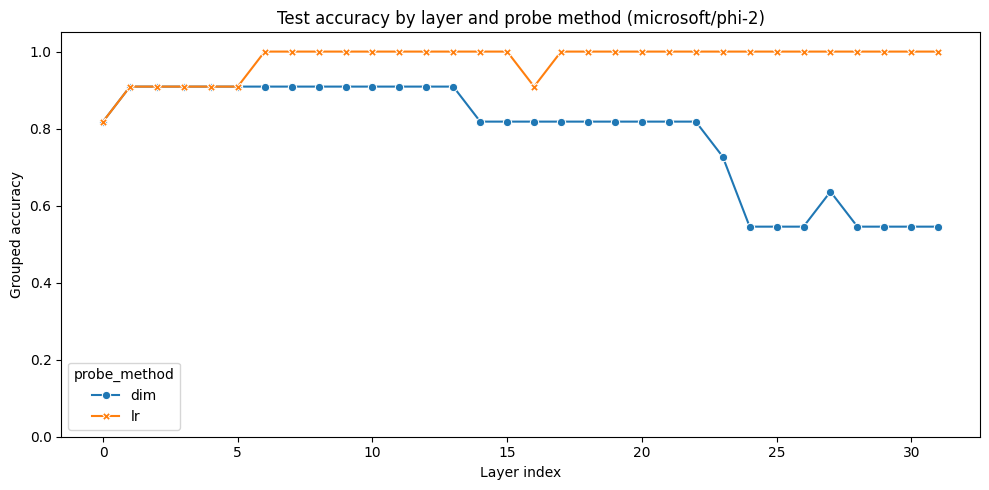

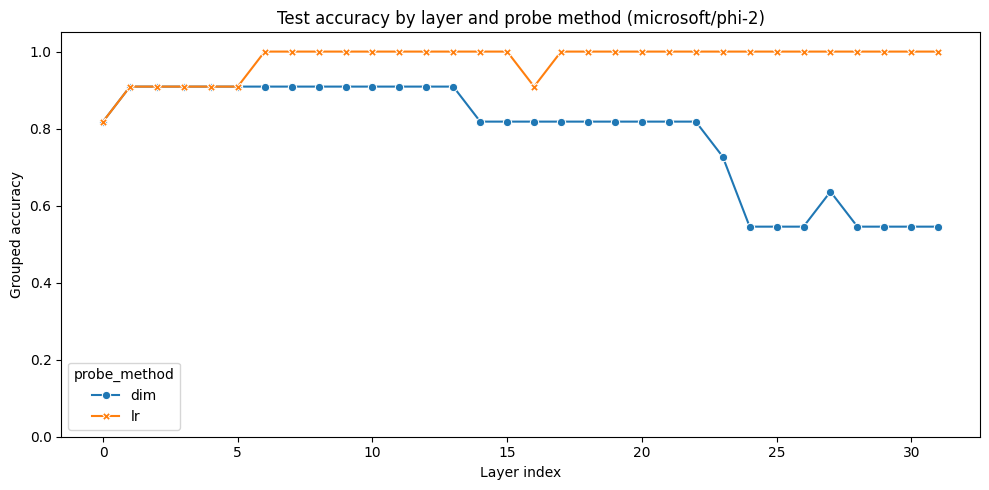

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=test_method_layers,
    x="layer",
    y="grouped_accuracy",
    hue="probe_method",
    style="probe_method",
    markers=True,
    dashes=False,
    ax=ax,
)
ax.set_ylim(0, 1.05)
ax.set_title(f"Test accuracy by layer and probe method ({MODEL_NAME})")
ax.set_xlabel("Layer index")
ax.set_ylabel("Grouped accuracy")
fig.tight_layout()
fig


## Interpretation

In the report, the layer sweep supports two claims:

- truthfulness is not equally readable from every layer,
- choosing the layer matters when comparing LLMs.

For the final multi-LLM comparison, use one fixed rule for all models, such as the last layer for a simple baseline or each model's best validation layer for a stronger analysis. The rule must be stated clearly.
